# Data Prep for Time to Injury Forecasting DeepHit Model

This script replicates this paper https://arxiv.org/html/2601.19479v1 that builds a time-to-injury forecasting model based on the DeebHit model and uses SoccerMon data

In [1]:
from subjective_metrics_pipeline import PlayerMetricsPipeline
from metrics_eda import MetricsEDA
from GPS_feature_extractor import GPSFeatureExtractor
from session_feature_extractor import SessionFeatureExtractor
from deephit_preprocessor import DeepHitPreprocessor

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, StandardScaler

## 1. Subjective Data Prep

In [2]:
# 1. Your exact, verified file paths
file_mapping = {
    'data/subjective/training-load/atl.csv': 'ATL',
    'data/subjective/training-load/weekly_load.csv': 'Weekly load',
    'data/subjective/training-load/monotony.csv': 'Monotony',
    'data/subjective/training-load/strain.csv': 'Strain',
    'data/subjective/training-load/acwr.csv': 'ACWR',
    'data/subjective/training-load/ctl28.csv': 'CTL28',
    'data/subjective/training-load/ctl42.csv': 'CTL42',
    'data/subjective/wellness/fatigue.csv': 'Fatigue',
    'data/subjective/wellness/mood.csv': 'Mood',
    'data/subjective/wellness/readiness.csv': 'Readiness',
    'data/subjective/wellness/sleep_duration.csv': 'Sleep duration',
    'data/subjective/wellness/soreness.csv': 'Soreness',
    'data/subjective/wellness/stress.csv': 'Stress'
}

# 3. Instantiate WITH the mapping dictionary explicitly
pipeline = PlayerMetricsPipeline(mapping=file_mapping)
final_df = pipeline.run()

# Display the first few rows
final_df.head()

🚀 Starting pipeline execution...

  ✅ Processed ATL: Generated 36550 rows.
  ✅ Processed Weekly load: Generated 36550 rows.
  ✅ Processed Monotony: Generated 36550 rows.
  ✅ Processed Strain: Generated 36550 rows.
  ✅ Processed ACWR: Generated 36550 rows.
  ✅ Processed CTL28: Generated 36550 rows.
  ✅ Processed CTL42: Generated 36550 rows.
  ✅ Processed Fatigue: Generated 36550 rows.
  ✅ Processed Mood: Generated 36550 rows.
  ✅ Processed Readiness: Generated 36550 rows.
  ✅ Processed Sleep duration: Generated 36550 rows.
  ✅ Processed Soreness: Generated 36550 rows.
  ✅ Processed Stress: Generated 36550 rows.

⏳ Formatting final schema. Total rows merged: 36550...
🎉 Pipeline complete! Final dataset shape: (36550, 15)


,player_name,date,ATL,Weekly load,Monotony,Strain,ACWR,CTL28,CTL42,Fatigue,Mood,Readiness,Sleep duration,Soreness,Stress
0,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Save to the current folder as a Parquet file
final_df.to_parquet("data/master_subjective_features.parquet", index=False)

print("✅ Saved as Parquet successfully!")

✅ Saved as Parquet successfully!


## 2. GPS Based Data Prep

In [ ]:
# 1. Initialize the extractor (set to 50Hz)
gps_pipeline = GPSFeatureExtractor(hz=50, is_ms=True)

# 2. Point it at your folder of 6 months of data
master_gps_df = gps_pipeline.process_directory("data/objective-TeamB-2020/2020")
# single_gps_df = gps_pipeline.process_single_file(file_path='data/objective-TeamB-2020/2020/2020-06/2020-06-01/2020-06-01-TeamB-2f23d7d5-2326-49ce-b9c8-5a6303f785c5.parquet')

print(master_gps_df.head())
# single_gps_df

Found 1837 Parquet files across all months. Starting batch extraction...
  -> Processed 50 / 1837 files...
  -> Processed 100 / 1837 files...
  -> Processed 150 / 1837 files...
  -> Processed 200 / 1837 files...
  -> Processed 250 / 1837 files...
  -> Processed 300 / 1837 files...
  -> Processed 350 / 1837 files...
  -> Processed 400 / 1837 files...
  -> Processed 450 / 1837 files...
  -> Processed 500 / 1837 files...
  -> Processed 550 / 1837 files...
  -> Processed 600 / 1837 files...
  -> Processed 650 / 1837 files...
  -> Processed 700 / 1837 files...
  -> Processed 750 / 1837 files...
  -> Processed 800 / 1837 files...
  -> Processed 850 / 1837 files...
  -> Processed 900 / 1837 files...
  -> Processed 950 / 1837 files...
  -> Processed 1000 / 1837 files...
  -> Processed 1050 / 1837 files...
  -> Processed 1100 / 1837 files...
  -> Processed 1150 / 1837 files...
  -> Processed 1200 / 1837 files...
  -> Processed 1250 / 1837 files...
  -> Processed 1300 / 1837 files...
  -> Proces

In [5]:
# Save to the current folder as a Parquet file
master_gps_df.to_parquet("data/master_gps_features.parquet", index=False)

print("✅ Saved as Parquet successfully!")

✅ Saved as Parquet successfully!


## 3. Session.json Data Prep

In [4]:
# 1. Initialize the extractor
session_pipeline = SessionFeatureExtractor("data/subjective/training-load/session.json")

# 2. Run the processing module
master_session_df = session_pipeline.process_daily_features()

# Save to the current folder as a Parquet file
master_session_df.to_parquet("data/master_session_features.parquet", index=False)

print("✅ Saved as Parquet successfully!")

Loading raw session data from data/subjective/training-load/session.json...
Aggregating sessions to daily level...
✅ Session data successfully processed into daily features.
✅ Saved as Parquet successfully!


## 4. Data Merge

In [4]:
def build_master_dataset(wellness_df: pd.DataFrame, session_df: pd.DataFrame, gps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merges Wellness, Session, and GPS data into a single longitudinal timeline 
    per player, and engineers structural missingness flags + rest day logic.
    """
    print("Initiating Master Merge Pipeline...")
    
    # 1. Ensure 'date' columns are standardized as strings or datetimes across all tables
    wellness_df['date'] = pd.to_datetime(wellness_df['date'])
    session_df['date'] = pd.to_datetime(session_df['date'])
    gps_df['date'] = pd.to_datetime(gps_df['date'])
    
    # 2. Merge 1: Wellness + Session
    print("  -> Merging Wellness & Session Data...")
    master_df = pd.merge(
        wellness_df, 
        session_df, 
        on=['date', 'player_name'], 
        how='outer'
    )
    
    # 3. Merge 2: (Wellness + Session) + GPS
    print("  -> Merging GPS Data...")
    master_df = pd.merge(
        master_df, 
        gps_df, 
        on=['date', 'player_name'], 
        how='outer'
    )
    
    # 4. Sort the timeline chronologically for each player
    master_df = master_df.sort_values(by=['player_name', 'date']).reset_index(drop=True)
    
    print("\n" + "="*40)
    print("POST-MERGE STRUCTURAL ENGINEERING")
    print("="*40)
    
    # A. GPS & Session Masks (Before any imputation)
    master_df['has_gps_data'] = master_df['Distance'].notnull().astype(int)
    master_df['has_session_data'] = master_df['duration obj'].notnull().astype(int)
    print("✅ Created 'has_gps_data' and 'has_session_data' masks.")

    # B. Wellness Mask
    wellness_cols = ['Fatigue', 'Mood', 'Readiness', 'Sleep duration', 'Soreness', 'Stress']
    existing_wellness_cols = [col for col in wellness_cols if col in master_df.columns]
    
    if existing_wellness_cols:
        # If any of the wellness columns are not null, they reported wellness that day
        master_df['wellness_reported'] = master_df[existing_wellness_cols].notnull().any(axis=1).astype(int)
        print("✅ Created 'wellness_reported' mask feature.")

    # C. Safe Zero-Filling for Objective Missing Data
    # If they didn't train, their physical output was physiologically zero.
    session_cols = ['daily_load', 'sRPE', 'duration obj', 'RPE']
    gps_cols = [col for col in gps_df.columns if col not in ['date', 'player_name']]
    
    for col in session_cols + gps_cols:
        if col in master_df.columns:
            master_df[col] = master_df[col].fillna(0)
    print("✅ Zero-filled missing physical load metrics.")

    # D. Extract "Rest Day" Signal 
    # Must be done AFTER zero-filling so the NaN days are now treated as 0-load rest days
    # We check for the column name variations to be safe
    if 'daily_load' in master_df.columns:
        master_df['is_rest_day'] = (master_df['daily_load'] == 0).astype(int)
    elif 'Daily load' in master_df.columns:
        master_df['is_rest_day'] = (master_df['Daily load'] == 0).astype(int)
    elif 'Strain' in master_df.columns:
        master_df['is_rest_day'] = (master_df['Strain'] == 0).astype(int)
        
    if 'is_rest_day' in master_df.columns:
        print("✅ Created 'is_rest_day' feature based on 0-load.")
            
    print("\n✅ Master Dataset built successfully!")
    print(f"Total shape: {master_df.shape}")
    
    return master_df

In [5]:
# ==========================================
# Execution
# ==========================================

raw_subjective_df = pd.read_parquet('data/master_subjective_features.parquet')
master_session_df = pd.read_parquet('data/master_session_features.parquet')
master_gps_df = pd.read_parquet('data/master_gps_features.parquet')

In [6]:
final_master_df = build_master_dataset(raw_subjective_df, master_session_df, master_gps_df)
# final_master_df.to_parquet('data/final_soccermon_dataset.parquet')
# display(final_master_df.head(10))

Initiating Master Merge Pipeline...
  -> Merging Wellness & Session Data...
  -> Merging GPS Data...

POST-MERGE STRUCTURAL ENGINEERING
✅ Created 'has_gps_data' and 'has_session_data' masks.
✅ Created 'wellness_reported' mask feature.
✅ Zero-filled missing physical load metrics.
✅ Created 'is_rest_day' feature based on 0-load.

✅ Master Dataset built successfully!
Total shape: (37315, 41)


## 5. EDA

2026-05-22 00:24:12,013 - INFO - Analyzing missing data...


Starting Sports Data EDA Suite...
----------------------------------------


c:\Users\GARETHE\Projects\Personal-Website\Injury Prediction\metrics_eda.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="mako")


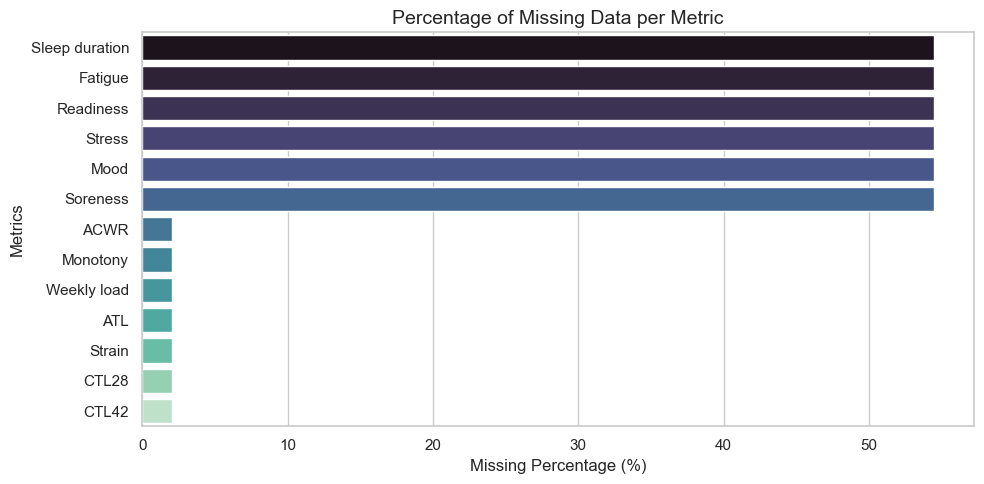

2026-05-22 00:24:12,540 - INFO - Plotting distributions and univariate outliers...


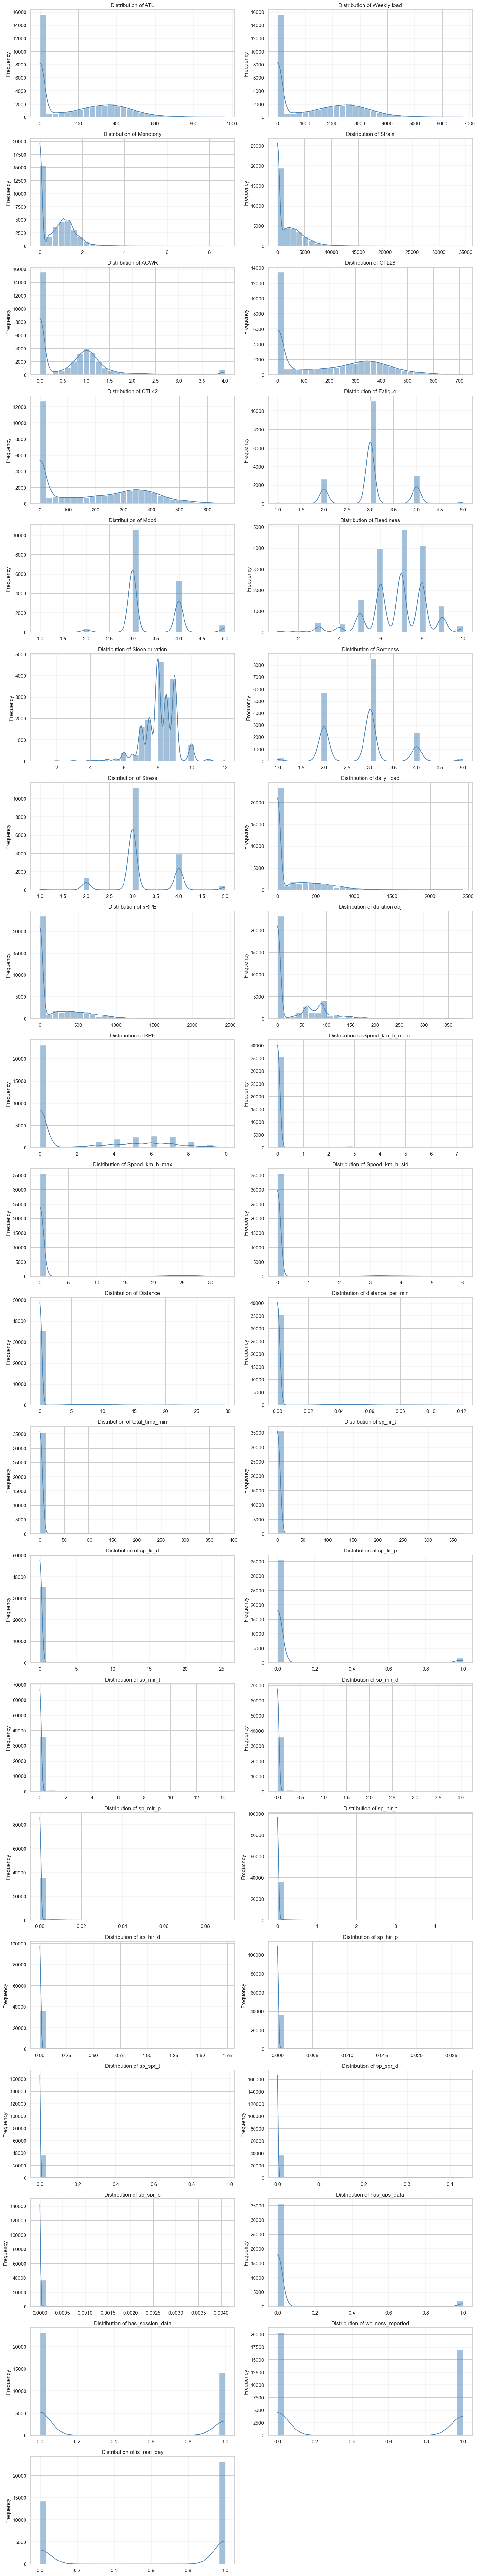

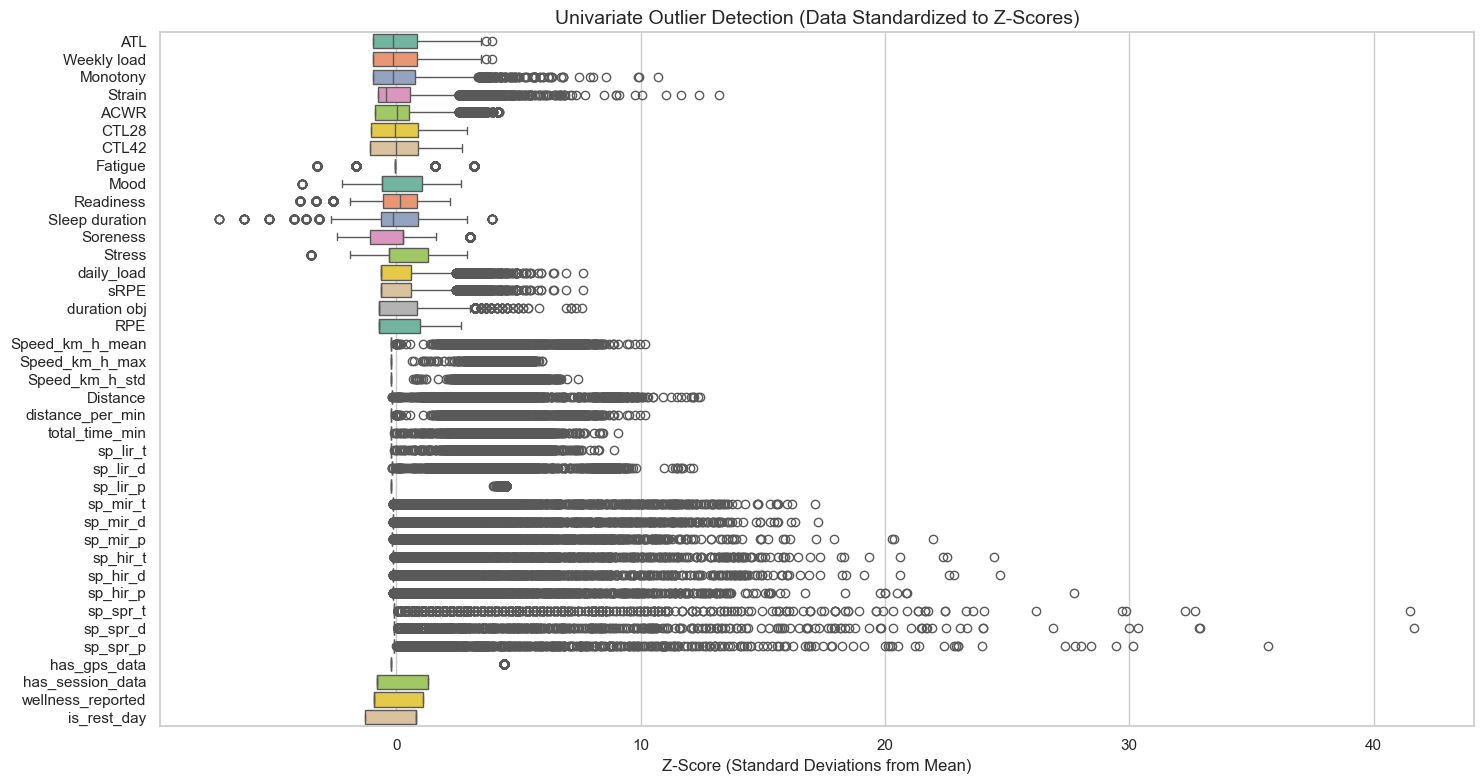

2026-05-22 00:24:31,499 - INFO - Generating correlation matrix...


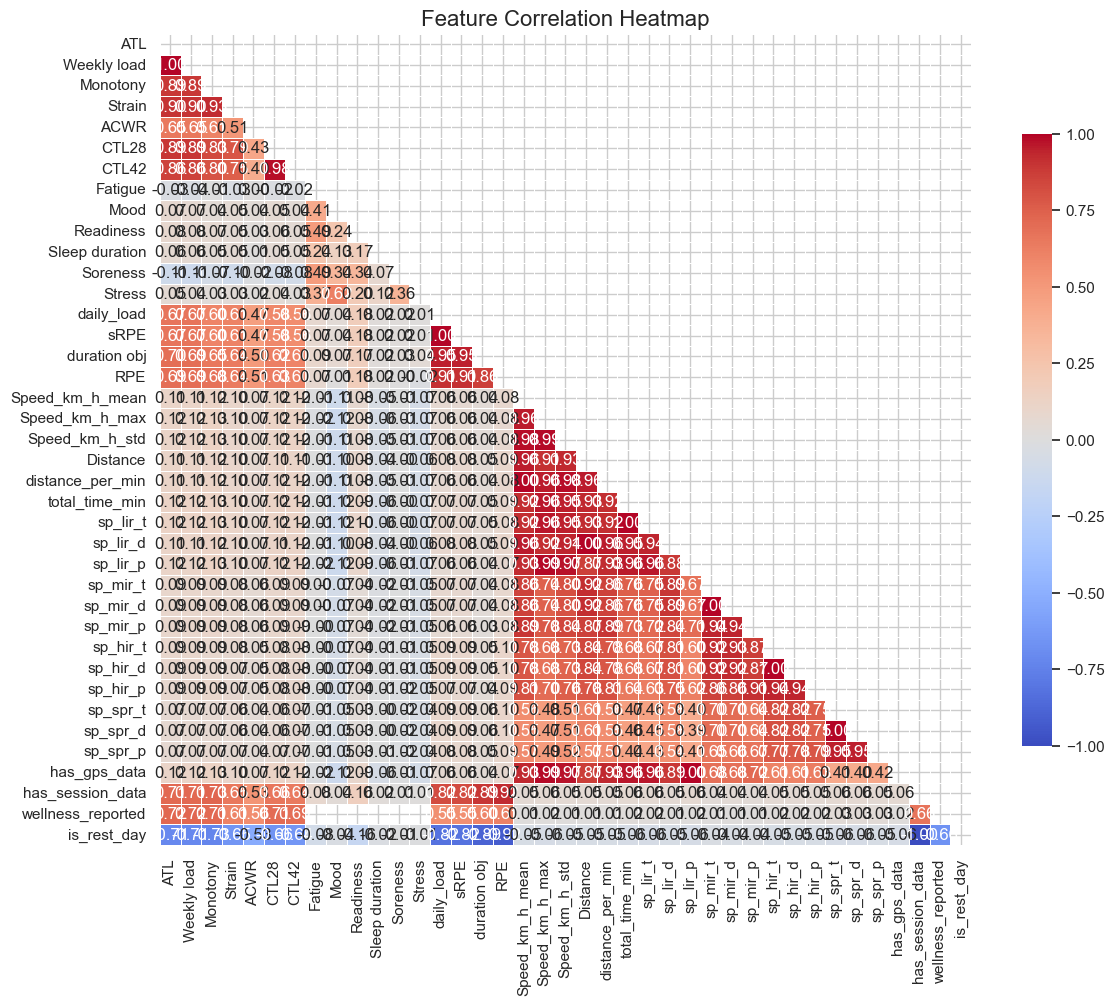

2026-05-22 00:24:32,732 - INFO - Plotting longitudinal trends for ['ATL', 'Readiness', 'Fatigue']...


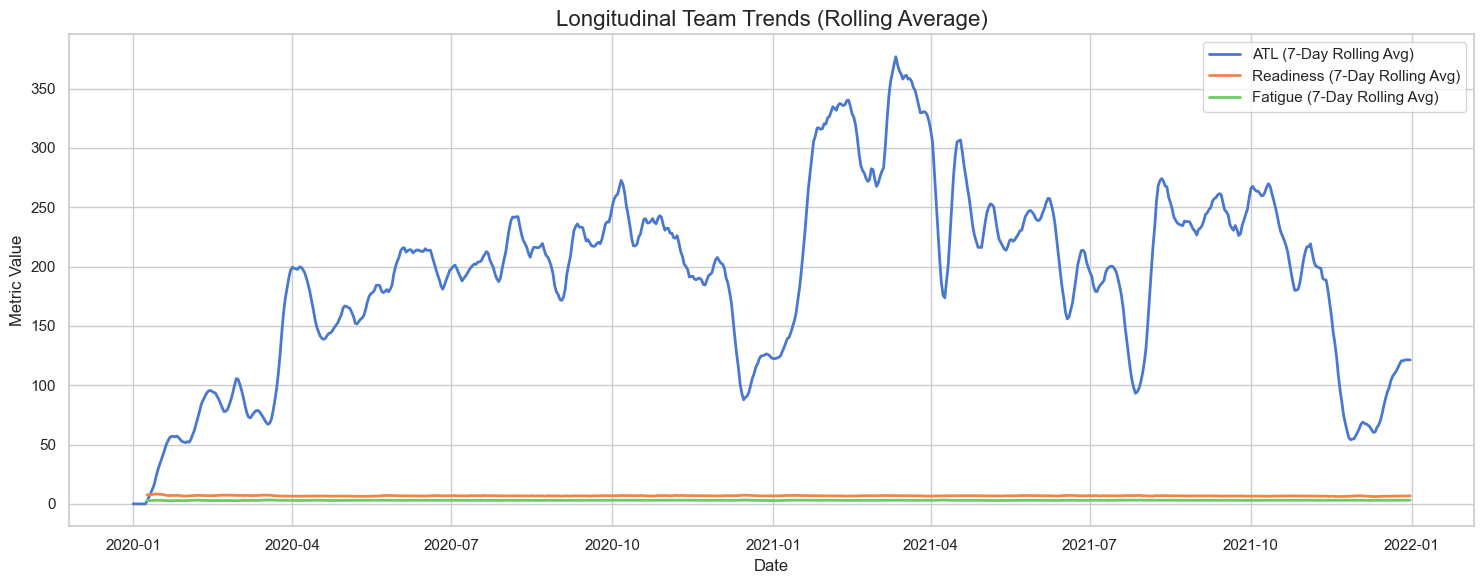

2026-05-22 00:24:32,982 - INFO - Running Isolation Forest for multivariate anomaly detection...
2026-05-22 00:24:32,991 - INFO - Columns used for Isolation Forest Index(['player_name', 'date', 'ATL', 'Weekly load', 'Monotony', 'Strain',
       'ACWR', 'CTL28', 'CTL42', 'Fatigue', 'Mood', 'Readiness',
       'Sleep duration', 'Soreness', 'Stress', 'daily_load', 'sRPE',
       'duration obj', 'RPE', 'Speed_km_h_mean', 'Speed_km_h_max',
       'Speed_km_h_std', 'Distance', 'distance_per_min', 'total_time_min',
       'sp_lir_t', 'sp_lir_d', 'sp_lir_p', 'sp_mir_t', 'sp_mir_d', 'sp_mir_p',
       'sp_hir_t', 'sp_hir_d', 'sp_hir_p', 'sp_spr_t', 'sp_spr_d', 'sp_spr_p',
       'has_gps_data', 'has_session_data', 'wellness_reported', 'is_rest_day'],
      dtype='str')
2026-05-22 00:24:33,321 - INFO - Detected 509 multivariate anomalies.


----------------------------------------
EDA Complete.


In [8]:
eda_pipeline = MetricsEDA(df=final_master_df)
multivariate_anomalies = eda_pipeline.run_all()

In [2]:
master_df = pd.read_parquet("data/final_soccermon_dataset.parquet")


In [3]:
# 1. Load your final merged dataset
master_df = pd.read_parquet("data/final_soccermon_dataset.parquet")

# 2. Chronological Split (Example: split at '2020-11-01')
train_df = master_df[master_df['date'] < '2020-11-01'].copy()
test_df = master_df[master_df['date'] >= '2020-11-01'].copy()

# 3. Initialize the processor
deephit_prep = DeepHitPreprocessor(lower_q=0.01, upper_q=0.99)

# 4. Fit & Transform the Training set
train_tensors = deephit_prep.fit_transform(train_df)

# 5. Transform the Testing set (Blindly)
test_tensors = deephit_prep.transform(test_df)

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...


2026-05-22 00:58:34,034 - INFO - Analyzing missing data...
2026-05-22 00:58:34,039 - INFO - No missing data found.
2026-05-22 00:58:34,041 - INFO - Plotting distributions and univariate outliers...


Starting Sports Data EDA Suite...
----------------------------------------


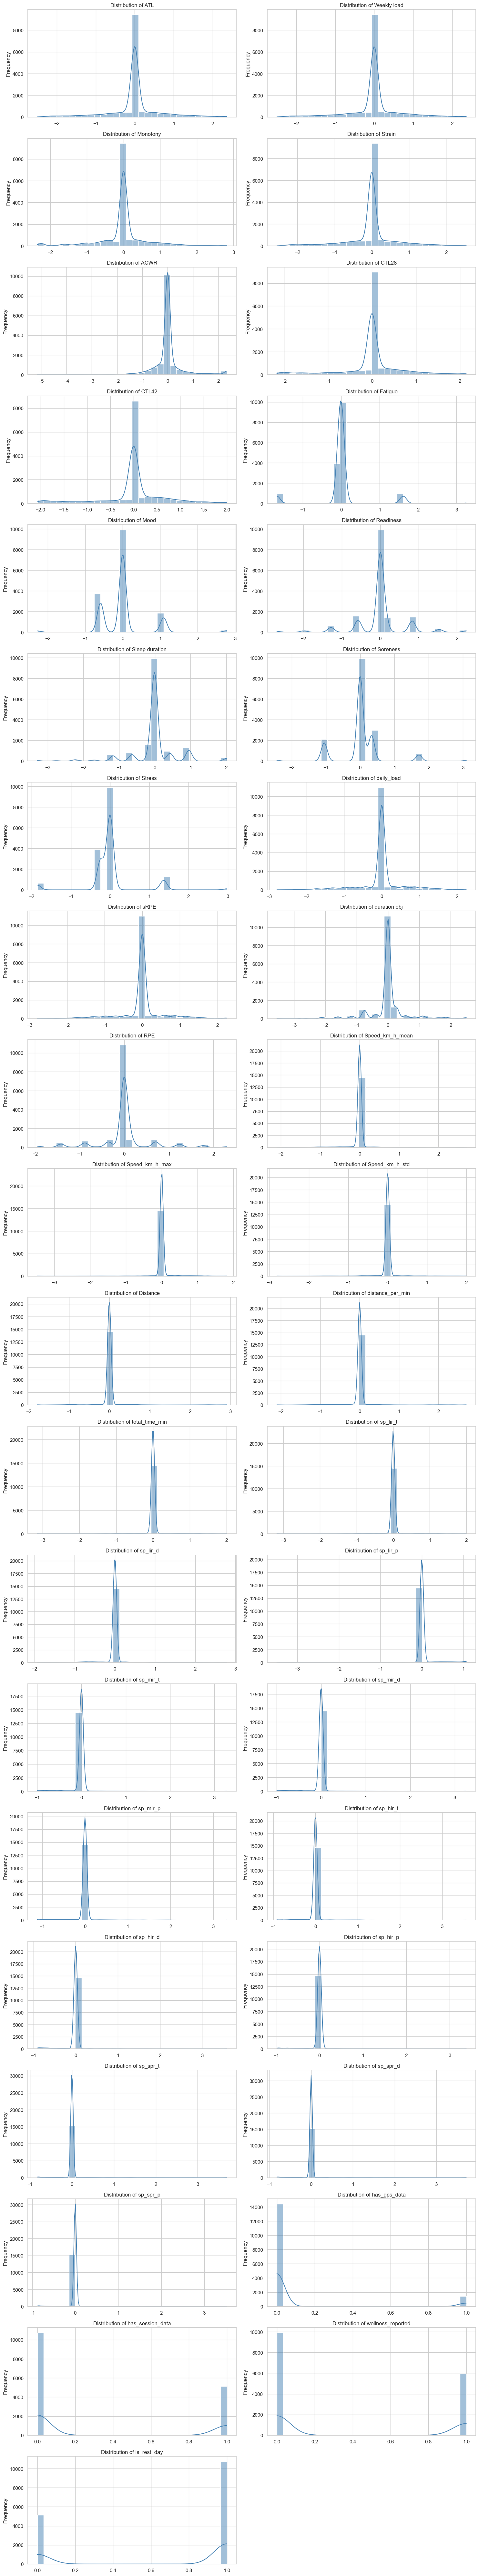

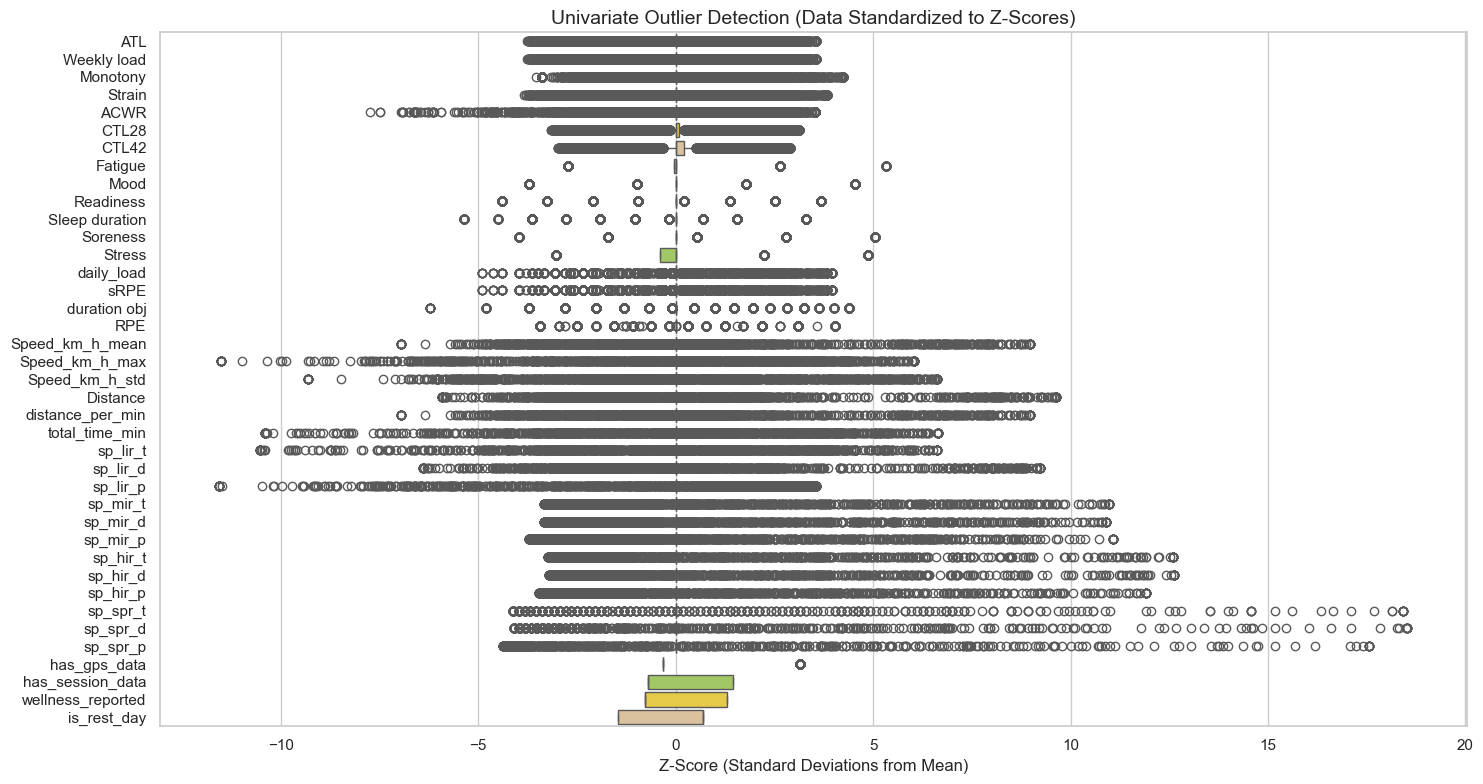

2026-05-22 00:58:57,556 - INFO - Generating correlation matrix...


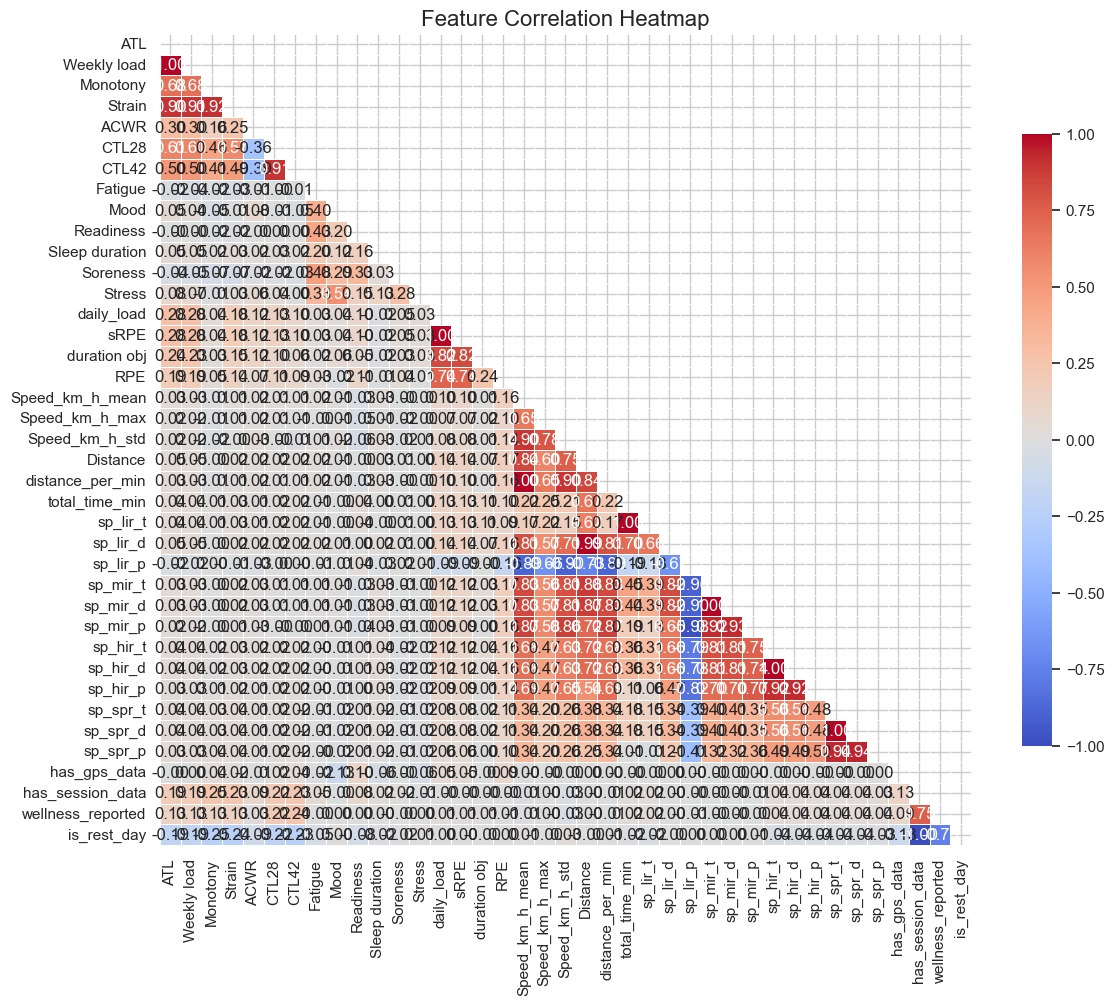

2026-05-22 00:59:00,743 - INFO - Plotting longitudinal trends for ['ATL', 'Readiness', 'Fatigue']...


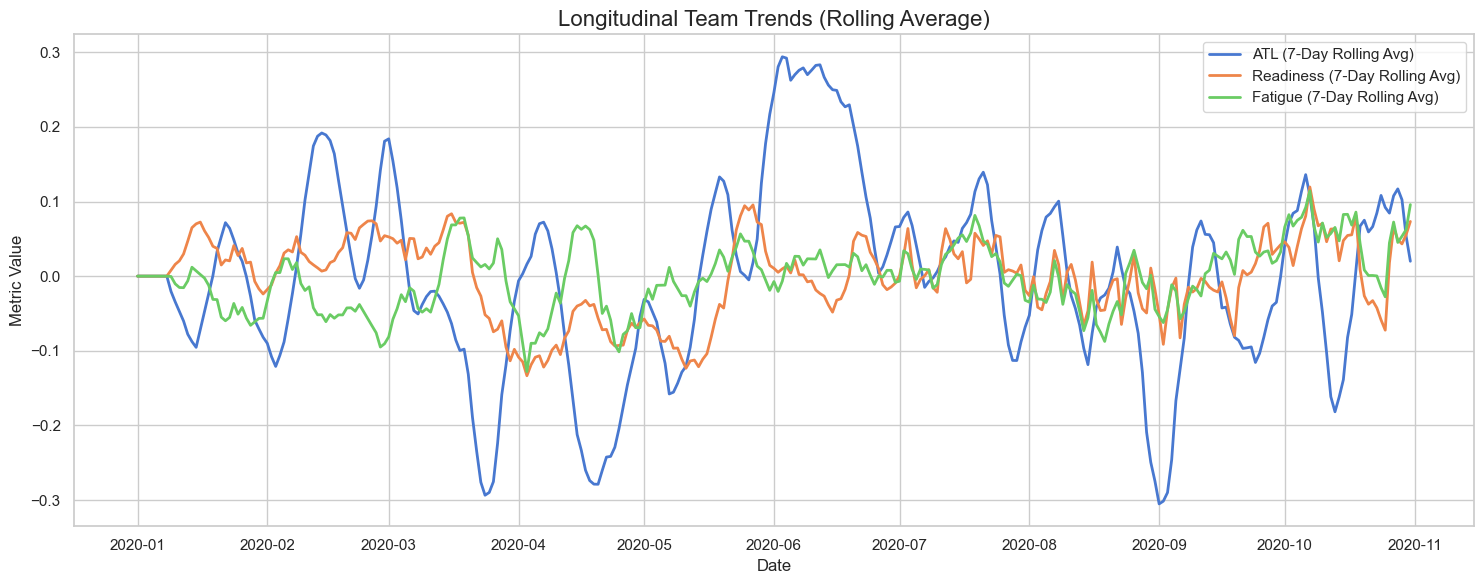

2026-05-22 00:59:01,836 - INFO - Running Isolation Forest for multivariate anomaly detection...
2026-05-22 00:59:01,846 - INFO - Columns used for Isolation Forest Index(['player_name', 'date', 'ATL', 'Weekly load', 'Monotony', 'Strain',
       'ACWR', 'CTL28', 'CTL42', 'Fatigue', 'Mood', 'Readiness',
       'Sleep duration', 'Soreness', 'Stress', 'daily_load', 'sRPE',
       'duration obj', 'RPE', 'Speed_km_h_mean', 'Speed_km_h_max',
       'Speed_km_h_std', 'Distance', 'distance_per_min', 'total_time_min',
       'sp_lir_t', 'sp_lir_d', 'sp_lir_p', 'sp_mir_t', 'sp_mir_d', 'sp_mir_p',
       'sp_hir_t', 'sp_hir_d', 'sp_hir_p', 'sp_spr_t', 'sp_spr_d', 'sp_spr_p',
       'has_gps_data', 'has_session_data', 'wellness_reported', 'is_rest_day'],
      dtype='str')
2026-05-22 00:59:02,147 - INFO - Detected 476 multivariate anomalies.


----------------------------------------
EDA Complete.


In [4]:
train_eda = MetricsEDA(df=train_tensors)
multivariate_anomalies = train_eda.run_all()

Steps taken for subjective data:

- Loaded in wide data and transfored to long version based on player_name and date
- Performed EDA to see proportions of missing data (missingness), feature distributions, box plots for outliers, correlation matrix and longitudinal team trends.
- To deal with missingess we used missingno pattern to find if the missingness is temporal (certain periods where all players are responsive) or individual (some players partake in the study while others don't).
- An engineered feature was created wellness_reported (0 or 1) to account for lazy individuals.
- Fixing feature distributions was to use Yeo-Johnson transformation for skewed data and standardscaler transform for standard columns.
- Outliers were dealt with by using winsorized clipping between the 1 and 55 percentiles
